# Exploración de Ground Truth — Estaciones de Precipitación en la Sabana de Bogotá

Este notebook identifica y evalúa las estaciones de precipitación disponibles dentro del dominio de estudio (~400×400 km centrado en Bogotá) y determina empíricamente qué años tienen cobertura suficiente para ser usados como ground truth en el modelo de nowcasting.

**Fuentes consultadas (datos.gov.co):**
- [Catálogo Nacional de Estaciones del IDEAM](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Cat-logo-Nacional-de-Estaciones-del-IDEAM/hp9r-jxuu/about_data) — `hp9r-jxuu`
- [Dataset de precipitación sub-horaria IDEAM/IDIGER](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Precipitaci-n/s54a-sgyg/about_data) — `s54a-sgyg`

**Decisiones que documenta este notebook:**
1. Qué estaciones incluir como ground truth
2. Qué años tienen datos suficientes y de calidad
3. Distribución espacial de las estaciones seleccionadas

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import time

In [ ]:
# En caso de reset de notebook
#candidatas = pd.read_csv('estaciones_sabana_candidatas.csv', dtype={'codigo': str})
#df_anual = pd.read_csv('precipitacion_anual_candidatas.csv', dtype={'codigoestacion': str})

## 1. Inventario de estaciones dentro del dominio

Consultamos el catálogo nacional de estaciones del IDEAM (`hp9r-jxuu`) filtrando por el bounding box del dominio de estudio: latitud entre 4.45°N y 5.05°N, longitud entre 74.35°O y 73.85°O. Este bbox corresponde aproximadamente a Bogotá D.C. y los municipios de la Sabana inmediata (Chía, Soacha, Facatativá, Zipaquirá, La Calera, entre otros).

In [2]:
url_catalogo = "https://www.datos.gov.co/resource/hp9r-jxuu.json"
params = {
    "$where": "latitud between 4.45 and 5.05 and longitud between -74.35 and -73.85",
    "$limit": 3000
}
# Incluir todas las estaciones del bbox
r = requests.get(url_catalogo, params=params)
estaciones = pd.DataFrame(r.json())

# Deduplicar por código numérico, quedándose con el código más largo (con ceros adelante)
# dado que es el formato que usa s54a-sgyg
estaciones['codigo_numerico'] = estaciones['codigo'].str.lstrip('0')
estaciones['largo_codigo'] = estaciones['codigo'].str.len()
estaciones = estaciones.sort_values('largo_codigo', ascending=False).drop_duplicates(
    subset='codigo_numerico', keep='first'
).drop(columns=['codigo_numerico', 'largo_codigo'])

print(f"Total estaciones únicas en bbox: {len(estaciones)}")
print(f"\nDistribución por categoría:")
print(estaciones['categoria'].value_counts())

Total estaciones únicas en bbox: 595

Distribución por categoría:
categoria
Limnimétrica               172
Pluviométrica              141
Climatológica Ordinaria     88
Climatológica Principal     60
Limnigráfica                53
Pluviográfica               35
Meteorológica Especial      31
HidroMeteorologica           6
Agrometeorológica            3
Radio Sonda                  2
Ambiental                    2
Sinóptica Secundaria         1
Sinóptica Principal          1
Name: count, dtype: int64


In [3]:
print(estaciones.head(4).to_string())

        codigo                                                        nombre                categoria                 tecnologia  estado departamento    municipio                                                                                                                         ubicaci_n altitud      longitud      latitud fecha_instalacion                             area_operativa area_hidrografica zona_hidrografica subzona_hidrografica                                                       entidad fecha_suspension corriente
17  2120500343                                     CERRO SAMPER [2120500343]            Pluviométrica  Automática sin Telemetría  Activa       Bogotá  Bogotá, D.C        {'latitude': '-74.01', 'longitude': '4.713388889', 'human_address': '{"address": "", "city": "", "state": "", "zip": ""}'}    3056        -74.01  4.713388889        01/02/2024  Area Operativa 11 - Cundinamarca-Amazonas   Magdalena Cauca    Alto Magdalena           Río Bogotá         EMPRESA DE 

### 1.1 Filtro por categoría

Para el ground truth de lluvia fuerte se necesitan estaciones que midan precipitación directamente. Las categorías útiles son Pluviométrica, Pluviográfica, Climatológica Principal y Climatológica Ordinaria, entre otras. Las *limnimétricas*, *limnigráficas*, *radio sonda* y *ambiental* miden niveles de río, perfil de atmósfera y calidad de aire (respectivamente), no precipitación.

Las estaciones HidroMeteorologica (6 en el bbox) se incluyen porque son automáticas con telemetría en Bogotá — probablemente miden precipitación además de nivel. Se verifica empíricamente al consultar el dataset de precipitación.

In [4]:
cats_excluir = ['Limnimétrica', 'Limnigráfica', 'Radio Sonda', 'Ambiental']

# Filtrar tipo de estaciones que no registran precipitaciones
candidatas = estaciones[~estaciones['categoria'].isin(cats_excluir)].copy()
candidatas = candidatas[['codigo', 'nombre', 'categoria', 'tecnologia', 'estado', 'municipio', 'latitud', 'longitud', 
                          'area_hidrografica', 'zona_hidrografica', 'subzona_hidrografica', 
                          'fecha_instalacion', 'fecha_suspension']].copy()

# Guardar inventario de candidatas
candidatas.to_csv('estaciones_sabana_candidatas.csv', index=False)

print(f"Candidatas después de filtro: {len(candidatas)}")
print("Guardado: estaciones_sabana_candidatas.csv")
print(candidatas.head(4).to_string())

Candidatas después de filtro: 366
Guardado: estaciones_sabana_candidatas.csv
        codigo                                                        nombre                categoria                 tecnologia  estado    municipio      latitud      longitud area_hidrografica zona_hidrografica subzona_hidrografica fecha_instalacion fecha_suspension
17  2120500343                                     CERRO SAMPER [2120500343]            Pluviométrica  Automática sin Telemetría  Activa  Bogotá, D.C  4.713388889        -74.01   Magdalena Cauca    Alto Magdalena           Río Bogotá        01/02/2024              NaN
21  2120000101                             ALTOS DE LA ESTANCIA [2120000101]            Pluviométrica  Automática con Telemetría  Activa  Bogotá, D.C      4.58074     -74.17828   Magdalena Cauca    Alto Magdalena           Río Bogotá        19/06/2018              NaN
0   0021205380                                         HIPOTECHO  [21205380]  Climatológica Ordinaria               

## 2. Verificación de disponibilidad de datos de precipitación

El catálogo del IDEAM confirma que las estaciones existen, pero no garantiza que sus datos de precipitación estén disponibles en el dataset `s54a-sgyg` de datos.gov.co. Este dataset contiene registros de precipitación a resolución sub-horaria (~5 minutos) de estaciones automáticas del IDEAM e IDIGER.

**Nota importante:** El portal DHIME del IDEAM solo expone precipitación diaria, mensual y anual — resolución insuficiente para definir eventos de lluvia fuerte horarios. El dataset `s54a-sgyg` es la única fuente pública con resolución sub-horaria identificada.

In [5]:
url_precip = "https://www.datos.gov.co/resource/s54a-sgyg.json"
resultados_anuales = []
errores = []

for i, cod in enumerate(candidatas['codigo'].dropna()):
    try:
        params = {
            "$select": "codigoestacion, date_trunc_y(fechaobservacion) AS anio, SUM(valorobservado) AS precip_total_mm, COUNT(*) AS n_registros",
            "$where": f"codigoestacion='{cod}'",
            "$group": "codigoestacion, date_trunc_y(fechaobservacion)",
            "$order": "anio ASC",
            "$limit": 100
        }
        r = requests.get(url_precip, params=params, timeout=30)
        data = r.json()
        if isinstance(data, list) and len(data) > 0:
            resultados_anuales.extend(data)
    except Exception as e:
        errores.append({'codigo': cod, 'error': str(e)})
    
    if (i + 1) % 50 == 0:
        print(f"{i+1}/{len(candidatas)} estaciones consultadas, {len(resultados_anuales)} filas acumuladas...")
    
    time.sleep(0.3)

df_anual = pd.DataFrame(resultados_anuales)
df_anual['anio'] = pd.to_datetime(df_anual['anio']).dt.year
df_anual['precip_total_mm'] = pd.to_numeric(df_anual['precip_total_mm'])
df_anual['n_registros'] = pd.to_numeric(df_anual['n_registros'])
df_anual.to_csv('precipitacion_anual_candidatas.csv', index=False)

print(f"\nListo. {len(df_anual)} filas guardadas.")
print(f"Estaciones con error: {len(errores)}")
if errores:
    print(errores)

50/366 estaciones consultadas, 145 filas acumuladas...
100/366 estaciones consultadas, 234 filas acumuladas...
150/366 estaciones consultadas, 286 filas acumuladas...
200/366 estaciones consultadas, 340 filas acumuladas...
250/366 estaciones consultadas, 360 filas acumuladas...
300/366 estaciones consultadas, 401 filas acumuladas...
350/366 estaciones consultadas, 479 filas acumuladas...

Listo. 479 filas guardadas.
Estaciones con error: 5
[{'codigo': '0021206780', 'error': "HTTPSConnectionPool(host='www.datos.gov.co', port=443): Read timed out. (read timeout=30)"}, {'codigo': '2120000106', 'error': "HTTPSConnectionPool(host='www.datos.gov.co', port=443): Read timed out. (read timeout=30)"}, {'codigo': '2120500135', 'error': "HTTPSConnectionPool(host='www.datos.gov.co', port=443): Read timed out. (read timeout=30)"}, {'codigo': '0021206280', 'error': "HTTPSConnectionPool(host='www.datos.gov.co', port=443): Read timed out. (read timeout=30)"}, {'codigo': '0021206990', 'error': "HTTPSCon

In [6]:
# Reintentar las estaciones con timeout
codigos_error = [e['codigo'] for e in errores]
resultados_reintento = []

for cod in codigos_error:
    try:
        params = {
            "$select": "codigoestacion, date_trunc_y(fechaobservacion) AS anio, SUM(valorobservado) AS precip_total_mm, COUNT(*) AS n_registros",
            "$where": f"codigoestacion='{cod}'",
            "$group": "codigoestacion, date_trunc_y(fechaobservacion)",
            "$order": "anio ASC",
            "$limit": 100
        }
        r = requests.get(url_precip, params=params, timeout=60)  # más tiempo
        data = r.json()
        if isinstance(data, list) and len(data) > 0:
            resultados_reintento.extend(data)
            print(f"OK: {cod} — {len(data)} filas")
        else:
            print(f"Sin datos: {cod}")
    except Exception as e:
        print(f"Error: {cod} — {e}")
    
    time.sleep(2)  # más pausa entre intentos

if resultados_reintento:
    df_reintento = pd.DataFrame(resultados_reintento)
    df_reintento['anio'] = pd.to_datetime(df_reintento['anio']).dt.year
    df_reintento['precip_total_mm'] = pd.to_numeric(df_reintento['precip_total_mm'])
    df_reintento['n_registros'] = pd.to_numeric(df_reintento['n_registros'])
    df_anual = pd.concat([df_anual, df_reintento], ignore_index=True)
    df_anual.to_csv('precipitacion_anual_candidatas.csv', index=False)
    print(f"\nTotal final: {len(df_anual)} filas guardadas.")

OK: 0021206780 — 9 filas
OK: 2120000106 — 7 filas
OK: 2120500135 — 8 filas
OK: 0021206280 — 8 filas
OK: 0021206990 — 20 filas

Total final: 531 filas guardadas.


### Verificación visual — estación de ejemplo

Para validar que la consulta a `s54a-sgyg` devuelve datos coherentes, comparamos el resultado contra la [visualización oficial del portal datos.gov.co](https://www.datos.gov.co/d/s54a-sgyg/visualization) para una estación de referencia (0021201980 — Cerro Guadalupe, Bogotá).

El gráfico muestra la precipitación total anual en mm. Sobre cada barra se indica el número de registros sub-horarios disponibles ese año ($n$), que sirve como proxy de la cobertura temporal real de la estación. Un año con pocos registros ($n$ bajo) puede tener precipitación total subestimada por gaps en la serie, no necesariamente porque llovió poco.

Nótese el gap entre 2016 y 2023 — ausencia de datos en el dataset para ese período — y la reactivación de la estación en 2024-2025 con cobertura alta ($n > 100,000$).

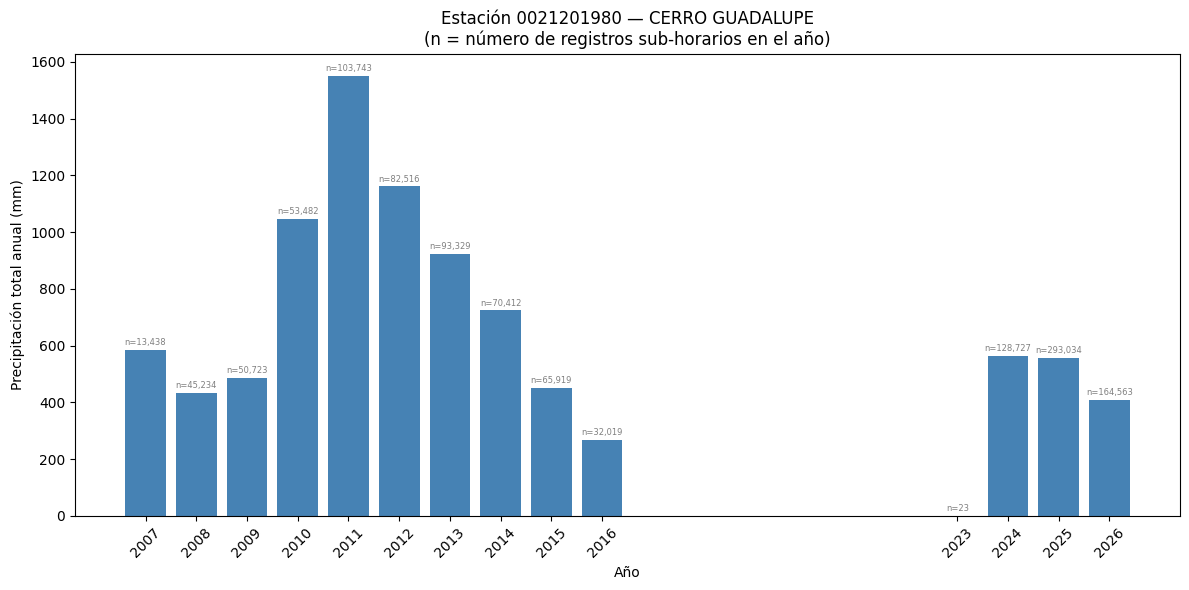

In [3]:
estacion = df_anual[df_anual['codigoestacion'] == '0021201980'].copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(estacion['anio'], estacion['precip_total_mm'], color='steelblue')

# Número de registros sobre cada barra
for bar, n_reg in zip(bars, estacion['n_registros']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={n_reg:,}', ha='center', va='bottom', fontsize=6, color='gray')

ax.set_xlabel('Año')
ax.set_ylabel('Precipitación total anual (mm)')
ax.set_title('Estación 0021201980 — CERRO GUADALUPE\n(n = número de registros sub-horarios en el año)')
ax.set_xticks(estacion['anio'])
ax.set_xticklabels(estacion['anio'], rotation=45)
plt.tight_layout()
plt.show()

Un segundo caso ilustra un patrón similar pero con inicio más tardío: la estación 0021206780 tiene registros entre 2012 y 2016, un gap entre 2017 y 2022, y reaparece en 2023-2026. En 2024 y 2025 alcanza coberturas de $n=189,990$ y $n=382,095$ respectivamente, consistentes con transmisión continua. El año 2014 muestra una precipitación anómalmente alta ($>1,300 mm$) que merece revisión antes de usarse como ground truth, aunque queda fuera del período de interés de esta tesis.

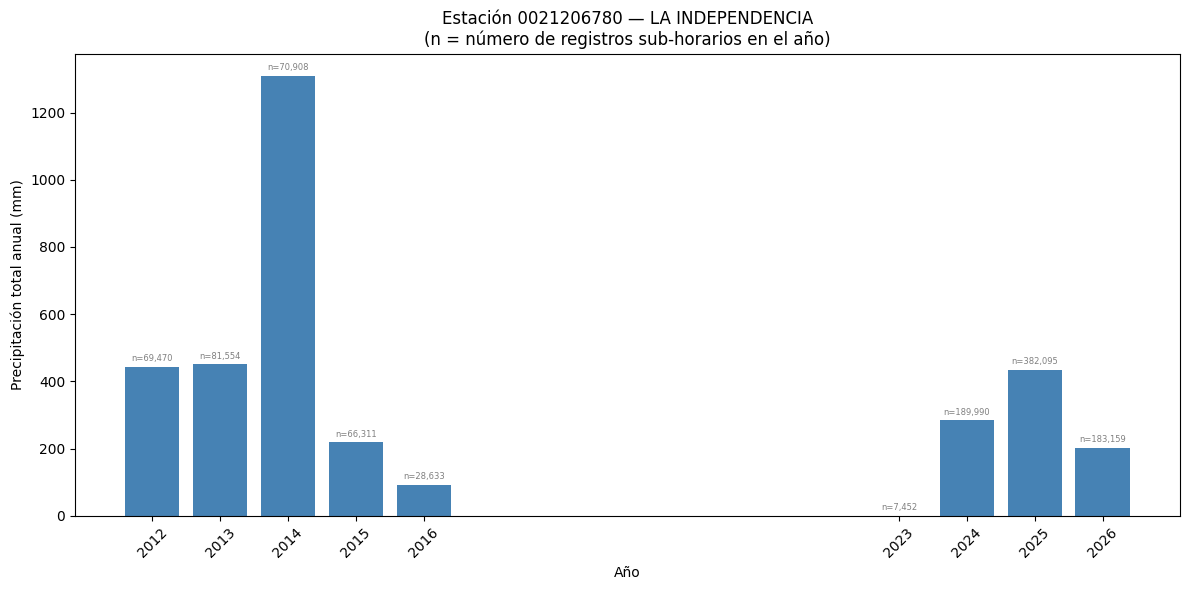

In [4]:
estacion = df_anual[df_anual['codigoestacion'] == '0021206780'].copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(estacion['anio'], estacion['precip_total_mm'], color='steelblue')

# Número de registros sobre cada barra
for bar, n_reg in zip(bars, estacion['n_registros']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={n_reg:,}', ha='center', va='bottom', fontsize=6, color='gray')

ax.set_xlabel('Año')
ax.set_ylabel('Precipitación total anual (mm)')
ax.set_title('Estación 0021206780 — LA INDEPENDENCIA\n(n = número de registros sub-horarios en el año)')
ax.set_xticks(estacion['anio'])
ax.set_xticklabels(estacion['anio'], rotation=45)
plt.tight_layout()
plt.show()

Un tercer caso revela un comportamiento distinto: la estación 0021206580 tiene datos continuos desde 2019 hasta 2026, incluyendo 2020, 2021 y 2022 — años que en varias de las estaciones chequeadas aparecen como gap. Esto confirma que la ausencia de datos en 2021-2022 no es un problema del dataset completo sino una característica heterogénea de la red: algunas estaciones mantuvieron transmisión continua mientras otras la interrumpieron. El análisis de cobertura que sigue cuantifica esta heterogeneidad estación por estación para los años de interés.

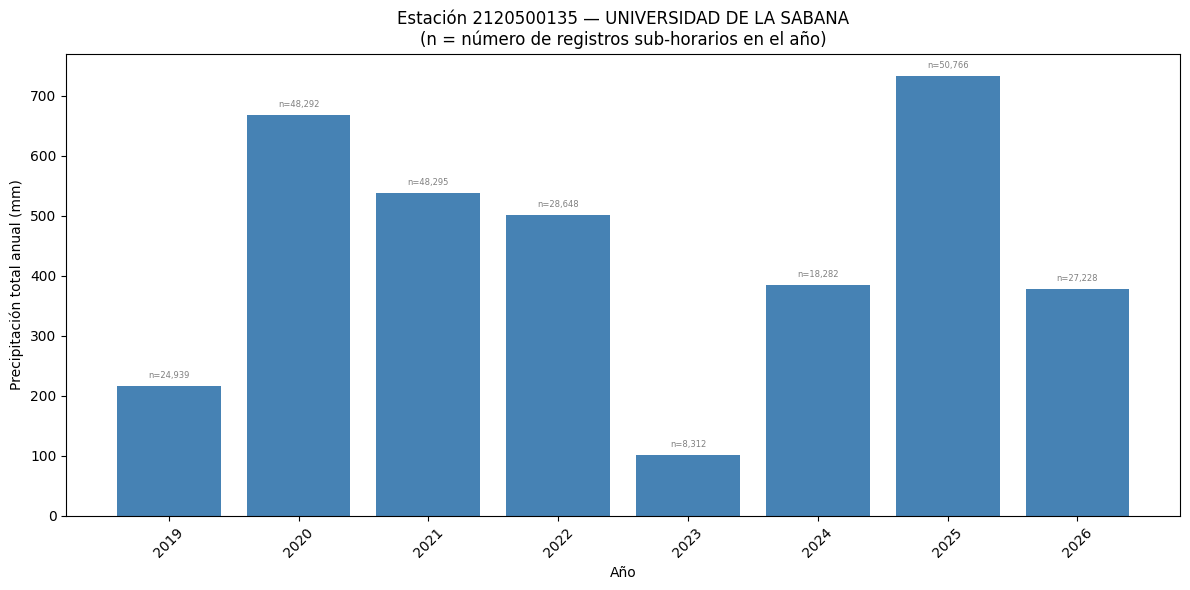

In [5]:
estacion = df_anual[df_anual['codigoestacion'] == '2120500135'].copy()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(estacion['anio'], estacion['precip_total_mm'], color='steelblue')

# Número de registros sobre cada barra
for bar, n_reg in zip(bars, estacion['n_registros']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={n_reg:,}', ha='center', va='bottom', fontsize=6, color='gray')

ax.set_xlabel('Año')
ax.set_ylabel('Precipitación total anual (mm)')
ax.set_title('Estación 2120500135 — UNIVERSIDAD DE LA SABANA\n(n = número de registros sub-horarios en el año)')
ax.set_xticks(estacion['anio'])
ax.set_xticklabels(estacion['anio'], rotation=45)
plt.tight_layout()
plt.show()

## 3. Selección de años candidatos

La disponibilidad de datos de precipitación sub-horaria no es homogénea a lo largo del tiempo: la red de estaciones ha cambiado en tamaño, densidad espacial y continuidad temporal entre 2018 y 2026. Para seleccionar los años que formarán el conjunto de datos de entrenamiento y validación del modelo, se combinan tres criterios: cobertura temporal 
(cuántos registros tiene cada estación-año), densidad espacial (cuántas estaciones activas hay y cómo se distribuyen sobre la Sabana), y continuidad temporal (ausencia de gaps que impidan una partición train/test limpia).

El análisis se organiza en tres pasos: 

- Primero se examina la distribución estadística de registros por estación-año;
- Luego se visualiza la distribución espacial de las estaciones activas para cada año; y,
- Finalmente se toma la decisión de inclusión o exclusión de cada año con base en los tres criterios combinados.

### 3.1 Filtro temporal inicial

El dataset `s54a-sgyg` contiene registros desde 2007, pero el análisis se restringe a partir de 2018 porque GOES-16 (el satélite que provee las variables de entrada del modelo) entró en operación en diciembre de 2017. No existe cobertura satelital útil para años anteriores, por lo que cualquier registro de precipitación previo a 2018 no tendría contraparte satelital con qué emparejarse.

In [6]:
df_anual = df_anual[df_anual['anio'] >= 2018].copy()
print(f"Filas después de filtrar desde 2018: {len(df_anual)}")

Filas después de filtrar desde 2018: 363


### 3.2 Distribución de registros por estación-año

Para entender la heterogeneidad de cobertura temporal entre estaciones y años, se visualiza la distribución del número de registros sub-horarios por año. Un número alto de registros indica transmisión continua durante el año; un número bajo indica gaps, instalación tardía, o baja frecuencia de transmisión.

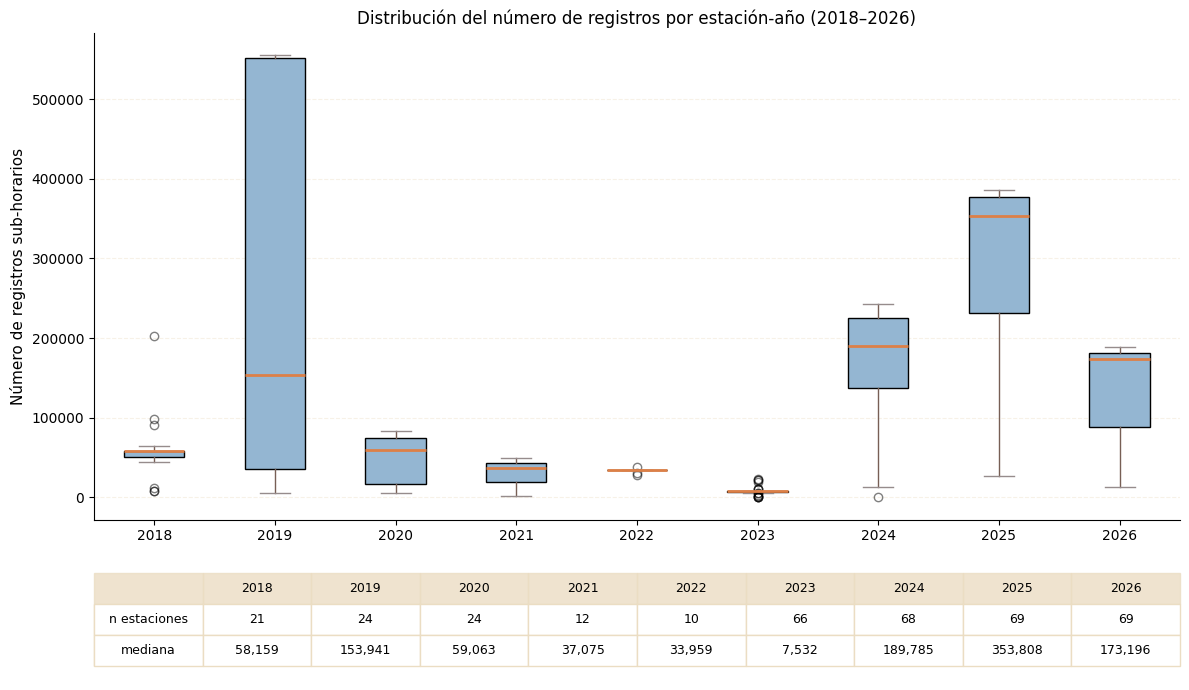

In [40]:
fig, (ax, ax_tabla) = plt.subplots(2, 1, figsize=(12, 7),
                                    gridspec_kw={'height_ratios': [4, 1]})

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

bp = ax.boxplot(data_por_año,
                tick_labels=años_orden,
                patch_artist=True,
                medianprops=dict(color='#DD8047', linewidth=2),
                boxprops=dict(facecolor='#94B6D2', alpha=1),
                whiskerprops=dict(color='#775F55'),
                capprops=dict(color='#968C8C'),
                flierprops=dict(marker='o', color='#968C8C', alpha=0.5))

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Número de registros sub-horarios', fontsize=11)
ax.set_title('Distribución del número de registros por estación-año (2018–2026)', fontsize=12)
ax.set_xticklabels(años_orden, fontsize=10)

# Tabla debajo
resumen = df_anual.groupby('anio').agg(
    n=('codigoestacion', 'count'),
    mediana=('n_registros', 'median')
).reset_index()

ax_tabla.axis('off')
tabla = ax_tabla.table(
    cellText=[
        ['n estaciones'] + [str(int(v)) for v in resumen['n']],
        ['mediana'] + [f"{int(v):,}" for v in resumen['mediana']]
    ],
    rowLabels=['', ''],
    colLabels=[''] + [str(int(a)) for a in resumen['anio']],
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 1.5)

# Colorear encabezados
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#EBDDC3')
        cell.set_alpha(0.8)
    cell.set_edgecolor('#EBDDC3')

plt.tight_layout()
plt.show()

El boxplot resume, para cada año, la distribución del número de registros sub-horarios entre todas las estaciones activas ese año. Cada punto que contribuye a una caja es el total de registros de una estación durante ese año (si en 2024 hay 68 estaciones, la caja de 2024 resume esos 68 valores). Una caja alta y centrada en valores altos indica que la mayoría de estaciones transmitieron de forma continua ese año; una caja baja o estrecha cerca de cero indica cobertura insuficiente o gaps generalizados.

Varios patrones son inmediatamente visibles:

- En 2019 la caja es anormalmente alta (mediana ~150,000 pero con valores hasta 550,000)
- En 2021-2022 las cajas son estrechas y bajas, con medianas alrededor de 30,000-35,000 registros (cobertura claramente insuficiente).
- En 2023 la mediana cae a ~7,500 registros, consistente con una red que se reactivó tarde en el año.
- En contraste, 2024 y 2025 muestran medianas altas (190,000 y 354,000 respectivamente) con cajas amplias pero centradas en valores altos, indicando cobertura continua en la mayoría de estaciones.
- 2026 tiene medianas similares a 2024 pero corresponde a un año incompleto (datos hasta julio).

In [8]:
# Cuántas estaciones tienen registros por año
resumen_anios = df_anual.groupby('anio').agg(
    n_estaciones=('codigoestacion', 'count'),
    mediana_registros=('n_registros', 'median'),
    p25_registros=('n_registros', lambda x: x.quantile(0.25)),
    p75_registros=('n_registros', lambda x: x.quantile(0.75))
).reset_index()

resumen_anios

,anio,n_estaciones,mediana_registros,p25_registros,p75_registros
0,2018,21,58159.0,50414.00,58453.00
1,2019,24,153941.0,35683.25,551834.75
2,2020,24,59063.0,16881.50,74536.75
3,2021,12,37075.5,19459.75,43523.25
4,2022,10,33959.5,33888.00,34250.75
5,2023,66,7532.5,7024.25,7846.00
6,2024,68,189785.5,137179.50,225596.00
7,2025,69,353808.0,231590.00,377236.00
8,2026,69,173196.0,88502.00,180882.00


### 3.3 Distribución espacial por año

La cobertura temporal de una estación es condición necesaria pero no suficiente: una red con muchas estaciones concentradas en un solo sector de la Sabana introduce sesgos espaciales en el ground truth, porque el modelo aprendería a predecir lluvia fuerte solo donde hay observaciones. Para evaluar la representatividad espacial de cada año, se mapean las estaciones activas sobre el dominio de estudio.

In [9]:
# Cruzar df_anual con coordenadas de candidatas
candidatas['latitud'] = pd.to_numeric(candidatas['latitud'])
candidatas['longitud'] = pd.to_numeric(candidatas['longitud'])

df_con_coords = df_anual.merge(
    candidatas[['codigo', 'latitud', 'longitud', 'categoria']],
    left_on='codigoestacion',
    right_on='codigo',
    how='left'
)

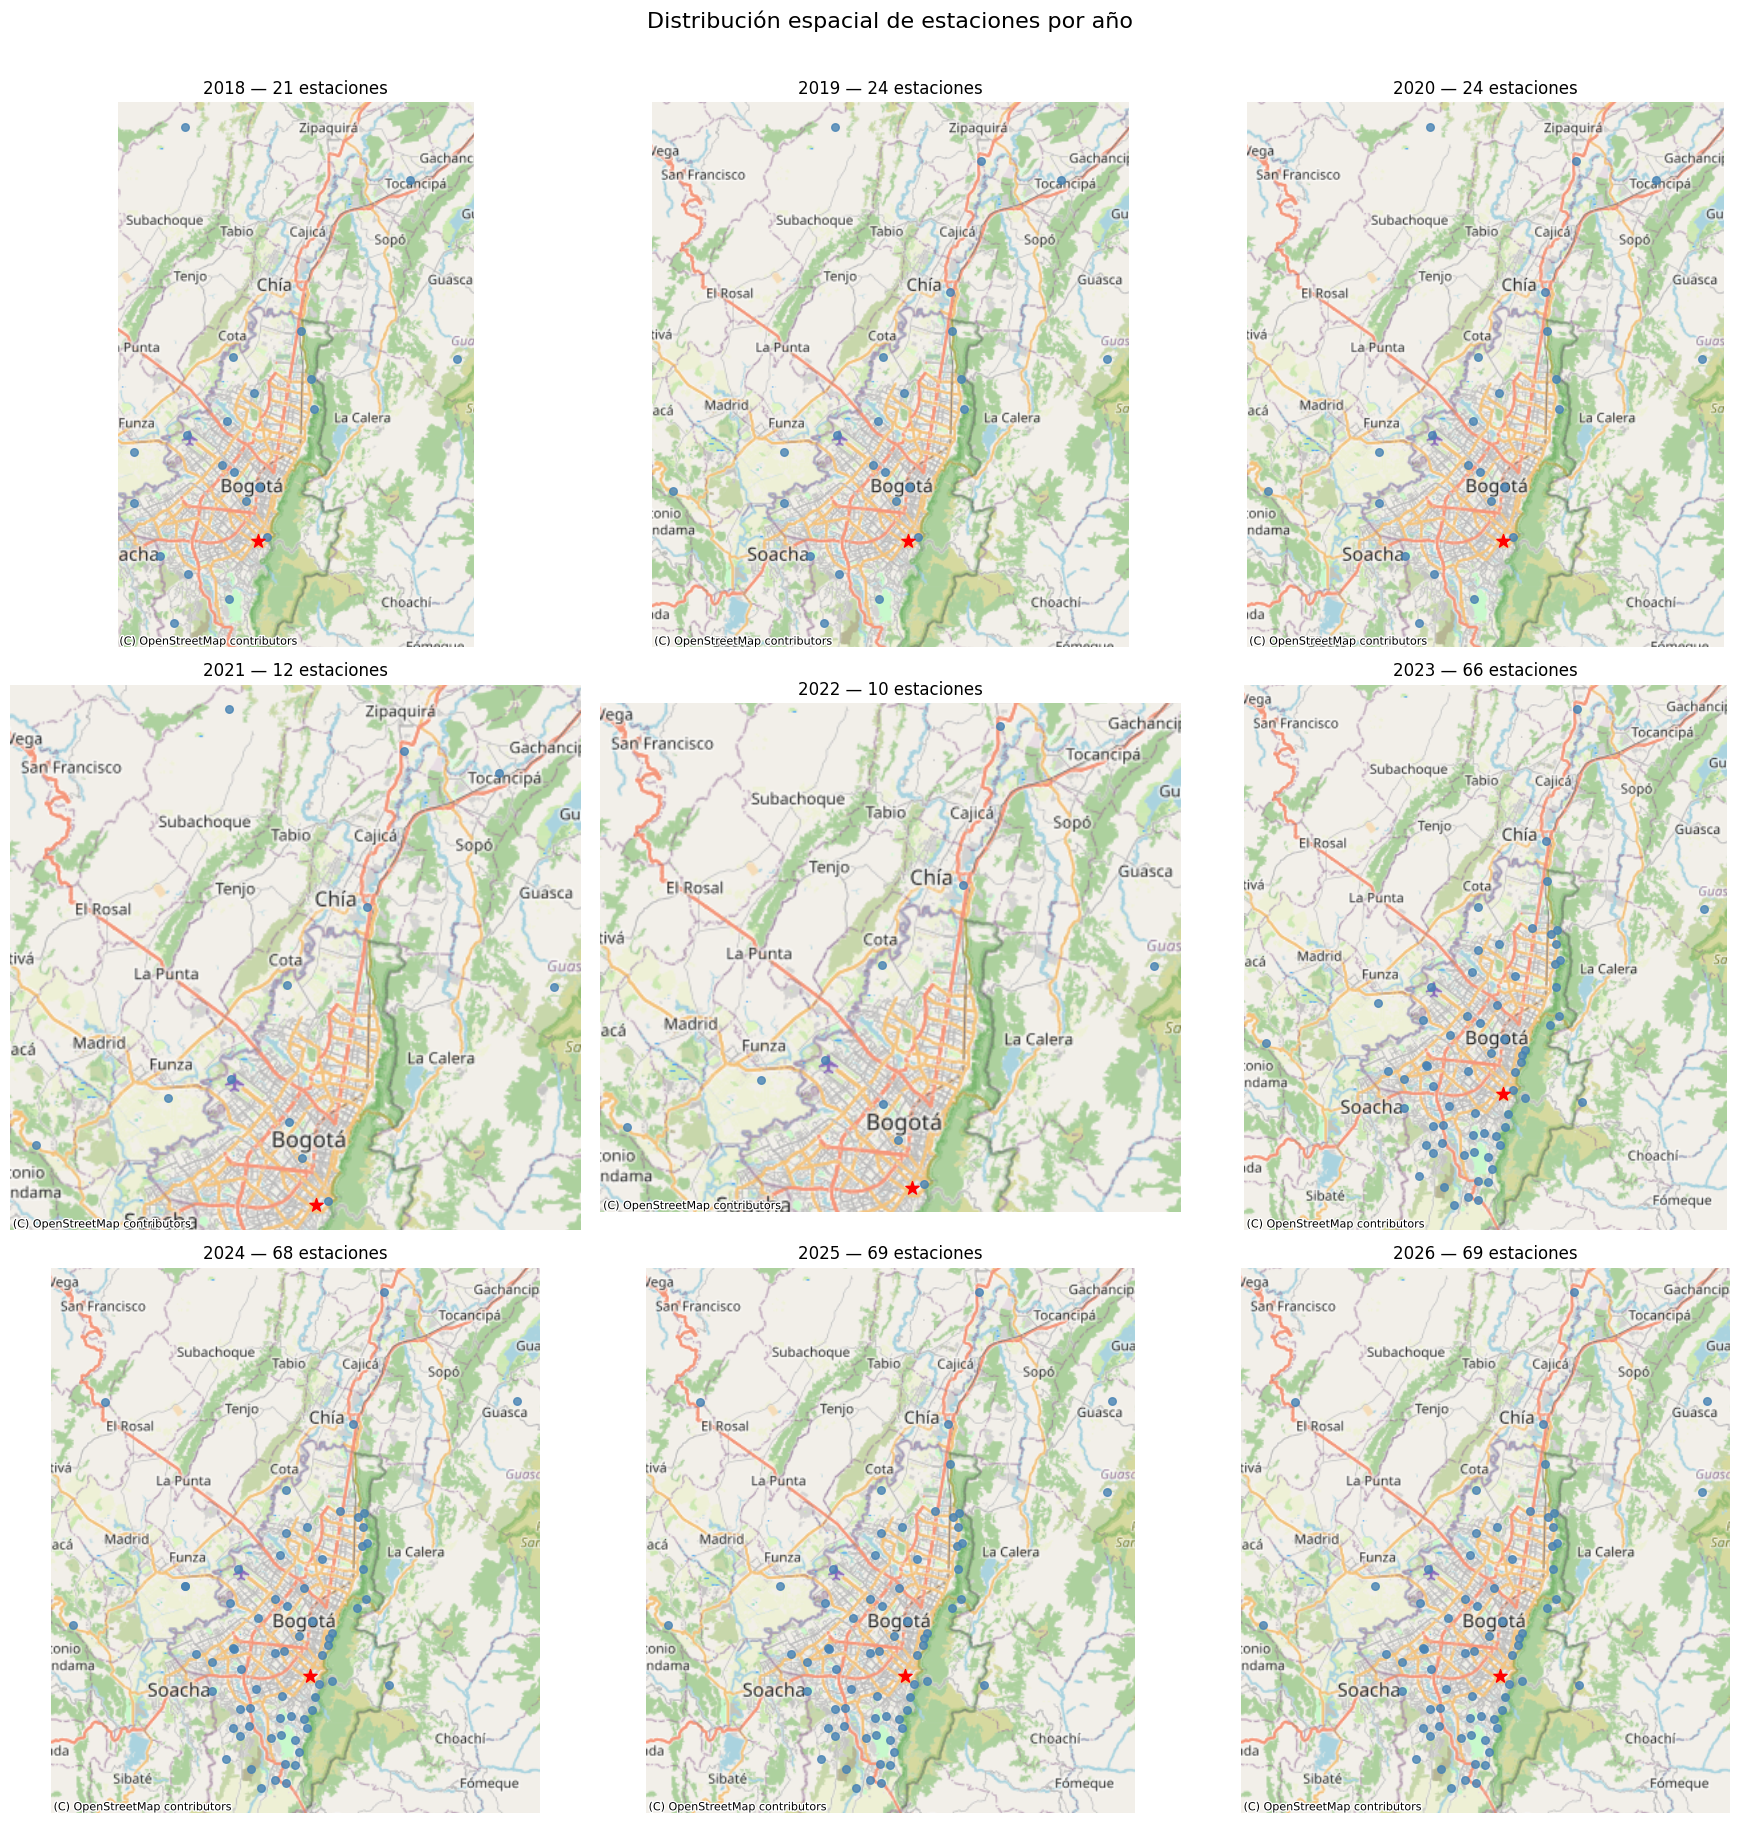

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

for idx, anio in enumerate(años_orden):
    df_año = df_con_coords[df_con_coords['anio'] == anio].dropna(subset=['latitud', 'longitud'])
    
    gdf_año = gpd.GeoDataFrame(
        df_año,
        geometry=[Point(xy) for xy in zip(df_año['longitud'], df_año['latitud'])],
        crs='EPSG:4326'
    ).to_crs(epsg=3857)
    
    centro = gpd.GeoDataFrame(
        geometry=[Point(-74.077, 4.596)], crs='EPSG:4326'
    ).to_crs(epsg=3857)
    
    ax = axes[idx]
    gdf_año.plot(ax=ax, color='steelblue', markersize=30, alpha=0.8, zorder=3)
    centro.plot(ax=ax, color='red', markersize=100, marker='*', zorder=4)
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)
    ax.set_title(f'{anio} — {len(df_año)} estaciones', fontsize=12)
    ax.set_axis_off()

plt.suptitle('Distribución espacial de estaciones por año', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('img-mapa_estaciones_por_año.png', dpi=150, bbox_inches='tight')
plt.show()

Los mapas muestran patrones claros. En 2018-2020 la red tiene 21-24 estaciones con distribución moderada sobre la Sabana, aunque con vacíos en el norte y el occidente. En 2021-2022 la red se contrae a 10-12 estaciones concentradas en el área urbana de Bogotá, dejando sin cobertura gran parte de la Sabana. A partir de 2023 la red se expande a 60+ estaciones con distribución homogénea sobre todo el dominio norte hasta Zipaquirá, occidente hasta Funza y Madrid, oriente hasta La Calera y Guasca.

### 3.4 Decisión de años candidatos

Combinando los tres criterios (cobertura temporal, densidad espacial y continuidad temporal) se toma la siguiente decisión para cada año:

| Año | Estaciones | Cobertura temporal | Distribución espacial | Decisión | Motivo |
|-----|-----------|-------------------|----------------------|----------|--------|
| 2018 | 21 | Media | Moderada | ❌ | Gap temporal 2021-2022 impide partición train/test continua |
| 2019 | 24 | Alta (inflada) | Moderada | ❌ | Duplicados sistemáticos en el dataset |
| 2020 | 24 | Baja | Moderada | ❌ | Gap temporal 2021-2022 impide partición train/test continua |
| 2021 | 12 | Baja | Insuficiente | ❌ | Red contraída, cobertura espacial insuficiente |
| 2022 | 10 | Baja | Insuficiente | ❌ | Red contraída, cobertura espacial insuficiente |
| 2023 | 66 | Muy baja (n~7,500) | Buena | ❌ | Mediana de registros insuficiente — red reactivada tardíamente |
| **2024** | **68** | **Alta (n~190,000)** | **Buena** | ✅ | Red densa, cobertura continua, distribución homogénea |
| **2025** | **69** | **Muy alta (n~354,000)** | **Buena** | ✅ | Red densa, cobertura continua, distribución homogénea |
| 2026 | 69 | Media | Buena | ❌ | Año incompleto (datos hasta julio 2026) |

Los años 2024 y 2025 son los únicos que satisfacen simultáneamente los tres criterios. La decisión de descartar 2018-2020 se basa en la discontinuidad temporal de la red entre 2021 y 2022, que impide construir una partición train/test temporal continua y podría introducir sesgos asociados al cambio en la densidad espacial del ground truth entre ambos bloques.

## 4. Conclusión

El ground truth del modelo de nowcasting estará compuesto por registros de precipitación sub-horaria de las estaciones de la red IDEAM/IDIGER ubicadas en la Sabana de Bogotá para los años 2024 y 2025. Estos son los únicos años 
que satisfacen simultáneamente los tres criterios de selección: cobertura temporal suficiente (medianas de 190,000 y 354,000 registros respectivamente), distribución espacial homogénea sobre el dominio de estudio (68-69 estaciones 
repartidas desde Zipaquirá hasta Soacha y desde Funza hasta La Calera), y continuidad temporal que permite una partición train/test sin gaps.

De las 70 estaciones con datos en alguno de los dos años, 67 están presentes en ambos, 1 solo en 2024 y 2 solo en 2025, una consistencia alta que facilita la comparación entre años y reduce el riesgo de sesgos espaciales entre el conjunto de entrenamiento y el de validación.

Los años anteriores fueron descartados por las siguientes razones: 
- 2018-2020 por la discontinuidad temporal de la red entre 2021 y 2022, que impide construir una partición train/test continua y podría introducir sesgos asociados al cambio en la densidad espacial del ground truth entre ambos bloques.
- 2021-2022 por cobertura espacial insuficiente.
- 2023 por cobertura temporal insuficiente (mediana de ~7,500 registros, consistente con una red reactivada tardíamente en el año).
- 2026 por ser un año incompleto.

*El siguiente paso es descargar los registros horarios de precipitación para estas 70 estaciones en 2024-2025, definir el umbral operativo de lluvia fuerte, y construir el conjunto de datos etiquetado que servirá para entrenar y validar el modelo.*

In [11]:
# Identificar estaciones por grupo
est_2024 = set(df_anual[df_anual['anio'] == 2024]['codigoestacion'])
est_2025 = set(df_anual[df_anual['anio'] == 2025]['codigoestacion'])

ambos = est_2024 & est_2025
solo_2024 = est_2024 - est_2025
solo_2025 = est_2025 - est_2024

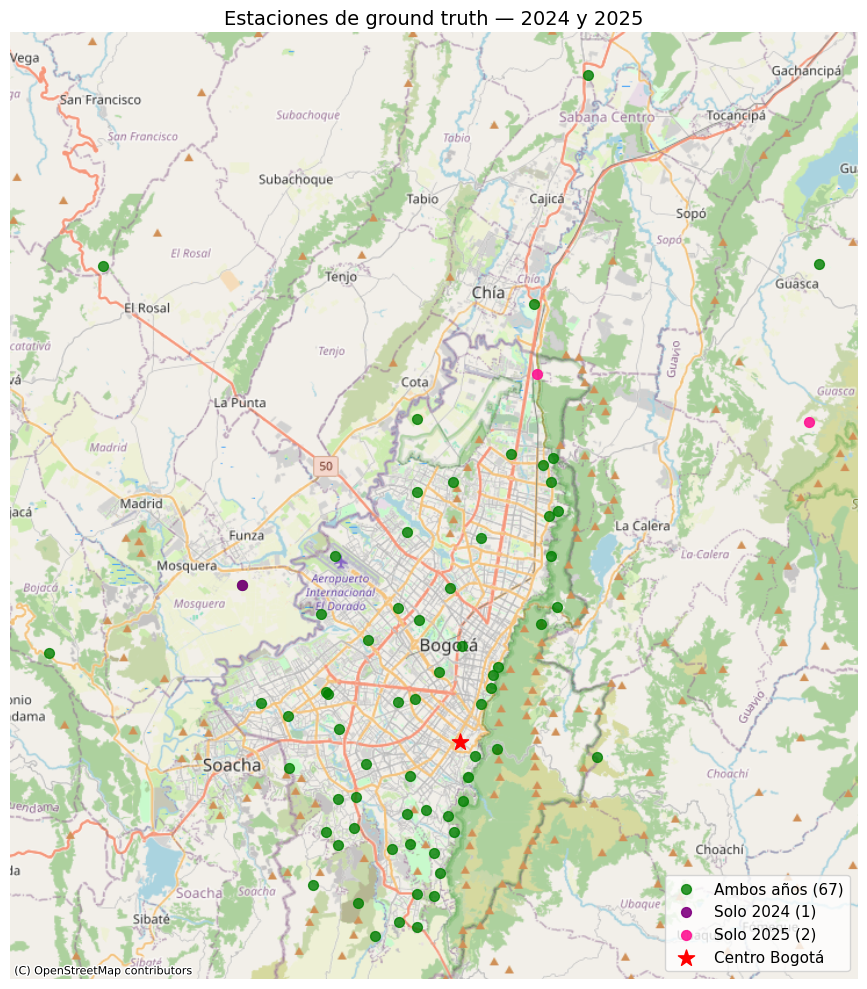

In [ ]:
# Preparar GeoDataFrames por grupo
def hacer_gdf(codigos, df_coords):
    df = df_coords[df_coords['codigoestacion'].isin(codigos)].drop_duplicates('codigoestacion')
    return gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df['longitud'], df['latitud'])],
        crs='EPSG:4326'
    ).to_crs(epsg=3857)

gdf_ambos = hacer_gdf(ambos, df_con_coords)
gdf_solo_2024 = hacer_gdf(solo_2024, df_con_coords)
gdf_solo_2025 = hacer_gdf(solo_2025, df_con_coords)
centro = gpd.GeoDataFrame(geometry=[Point(-74.077, 4.596)], crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_ambos.plot(ax=ax, color='green', markersize=50, alpha=0.8, zorder=3, label=f'Ambos años ({len(ambos)})')
gdf_solo_2024.plot(ax=ax, color='purple', markersize=50, alpha=0.9, zorder=4, label=f'Solo 2024 ({len(solo_2024)})')
gdf_solo_2025.plot(ax=ax, color='deeppink', markersize=50, alpha=0.9, zorder=4, label=f'Solo 2025 ({len(solo_2025)})')
centro.plot(ax=ax, color='red', markersize=150, marker='*', zorder=5, label='Centro Bogotá')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_title('Estaciones de ground truth — 2024 y 2025', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('img-mapa_estaciones-step_exploration.png', dpi=200, bbox_inches='tight')
plt.show()